---
## **Notebook para estudo das gerações de dados em censuras localizadas**
---

In [2]:
source("/workspaces/estudo_de_adequabilidade_de_poder_de_teste/funcoes_final_1.R")


Attaching package: ‘survival’


The following object is masked from ‘package:Rlab’:

    cancer


Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




---
### **Riscos Proporcionais**

In [101]:
### =========================================== APLICACAO ======================= ###
n <- 500
pi <- 0.5
taxa_censura <- 0.3
parametro_falha_experimental <- 10 
parametro_falha_controle <- 5
parametro_censura_experimental <- parametro_falha_experimental * (1 - taxa_censura) / taxa_censura
parametro_censura_controle <- parametro_falha_controle * (1 - taxa_censura) / taxa_censura
distribuicao <- "weibull"
shape_falha_experimental_weibull <- 0.5
shape_falha_controle_weibull <- 0.5
shape_censura_experimental_weibull <- shape_falha_experimental_weibull
shape_censura_controle_weibull <- shape_falha_controle_weibull


=== Relatório da Simulação ===
Grupo Experimental (A) - Censura Observada: 35.0%
Grupo Controle     (B) - Censura Observada: 38.6%


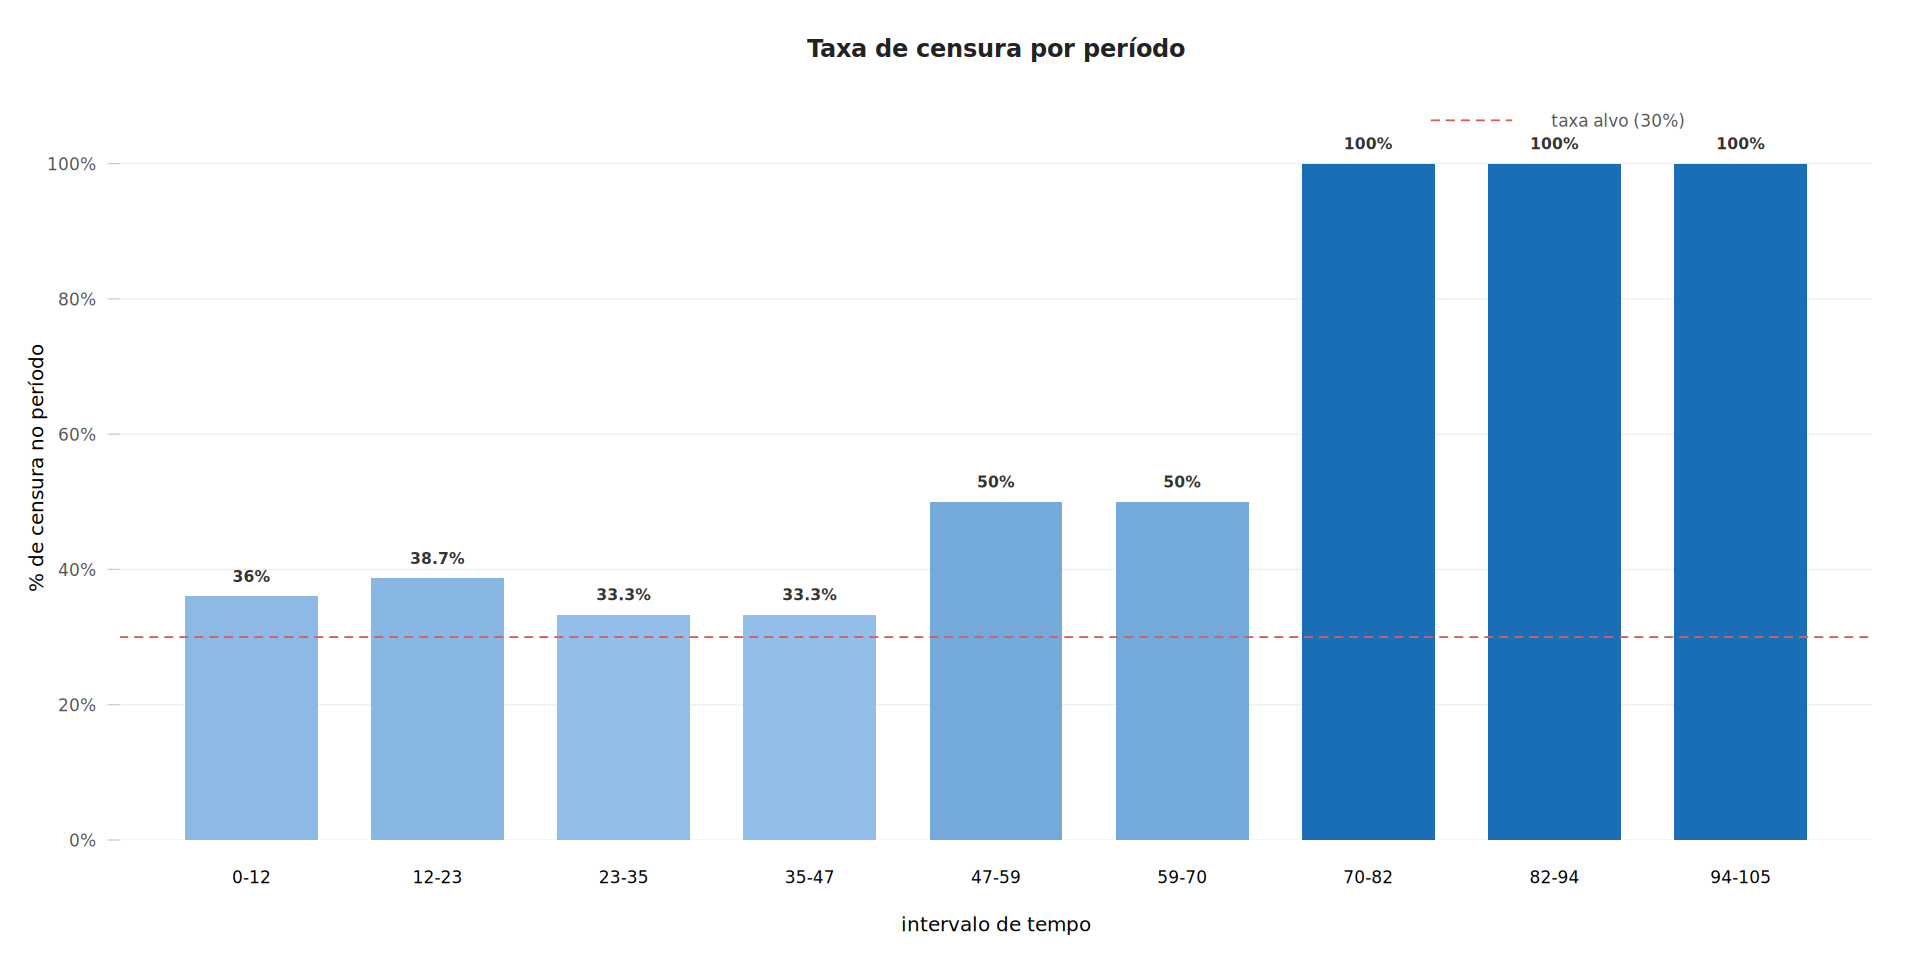

In [113]:
dados <- exemplo(distribuicao, n, pi, 
                    parametro_falha_experimental, parametro_falha_controle, 
                    parametro_censura_experimental, parametro_censura_controle,
                    shape_falha_experimental_weibull, shape_censura_experimental_weibull, 
                    shape_falha_controle_weibull, shape_censura_controle_weibull, 
                    sdlog_falha_experimental, sdlog_censura_experimental, 
                    sdlog_falha_controle, sdlog_censura_controle)

censurados <- dados[dados$delta == 0, ]

breaks <- seq(0, max(dados$z), length.out = 10)

intervalo_todos      <- cut(dados$z,      breaks = breaks, include.lowest = TRUE)
intervalo_censurados <- cut(censurados$z, breaks = breaks, include.lowest = TRUE)

total_intervalo      <- table(intervalo_todos)
censurados_intervalo <- table(intervalo_censurados)

pct_censura <- as.numeric(censurados_intervalo / total_intervalo * 100)
pct_censura[is.nan(pct_censura)] <- 0

# Rótulos simplificados: só o início do intervalo
rotulos <- paste0(round(breaks[-length(breaks)], 0), "-", round(breaks[-1], 0))

cores <- colorRampPalette(c("#cce5ff", "#1a6eb5"))(100)
indices_cor <- pmax(1, pmin(100, round(pct_censura)))
cores_barras <- cores[indices_cor]

par(bg = "white", mar = c(5, 5, 4, 2), family = "sans")

bp <- barplot(
  pct_censura,
  names.arg = rotulos,
  col       = cores_barras,
  border    = NA,
  ylim      = c(0, 110),
  axes      = FALSE,
  las       = 1,      # rótulos horizontais — sem rotação
  cex.names = 0.85,
  space     = 0.4
)

axis(2, at = seq(0, 100, 20),
     labels = paste0(seq(0, 100, 20), "%"),
     las = 1, col = NA, col.ticks = "#cccccc",
     col.axis = "#555555", cex.axis = 0.85)

abline(h = seq(0, 100, 20), col = "#eeeeee", lwd = 1)

barplot(pct_censura, col = cores_barras, border = NA,
        axes = FALSE, add = TRUE, space = 0.4)

abline(h = 30, col = "#e05a5a", lty = 2, lwd = 1.5)

text(x      = bp,
     y      = pct_censura + 3,
     labels = ifelse(pct_censura > 0, paste0(round(pct_censura, 1), "%"), ""),
     cex    = 0.78,
     col    = "#333333",
     font   = 2)

title(
  main     = "Taxa de censura por período",
  col.main = "#222222", cex.main = 1.2, font.main = 2,
  xlab     = "intervalo de tempo",
  ylab     = "% de censura no período"
)

legend("topright",
       legend   = "taxa alvo (30%)",
       col      = "#e05a5a",
       lty = 2, lwd = 1.5,
       bty      = "n",
       cex      = 0.85,
       text.col = "#555555")

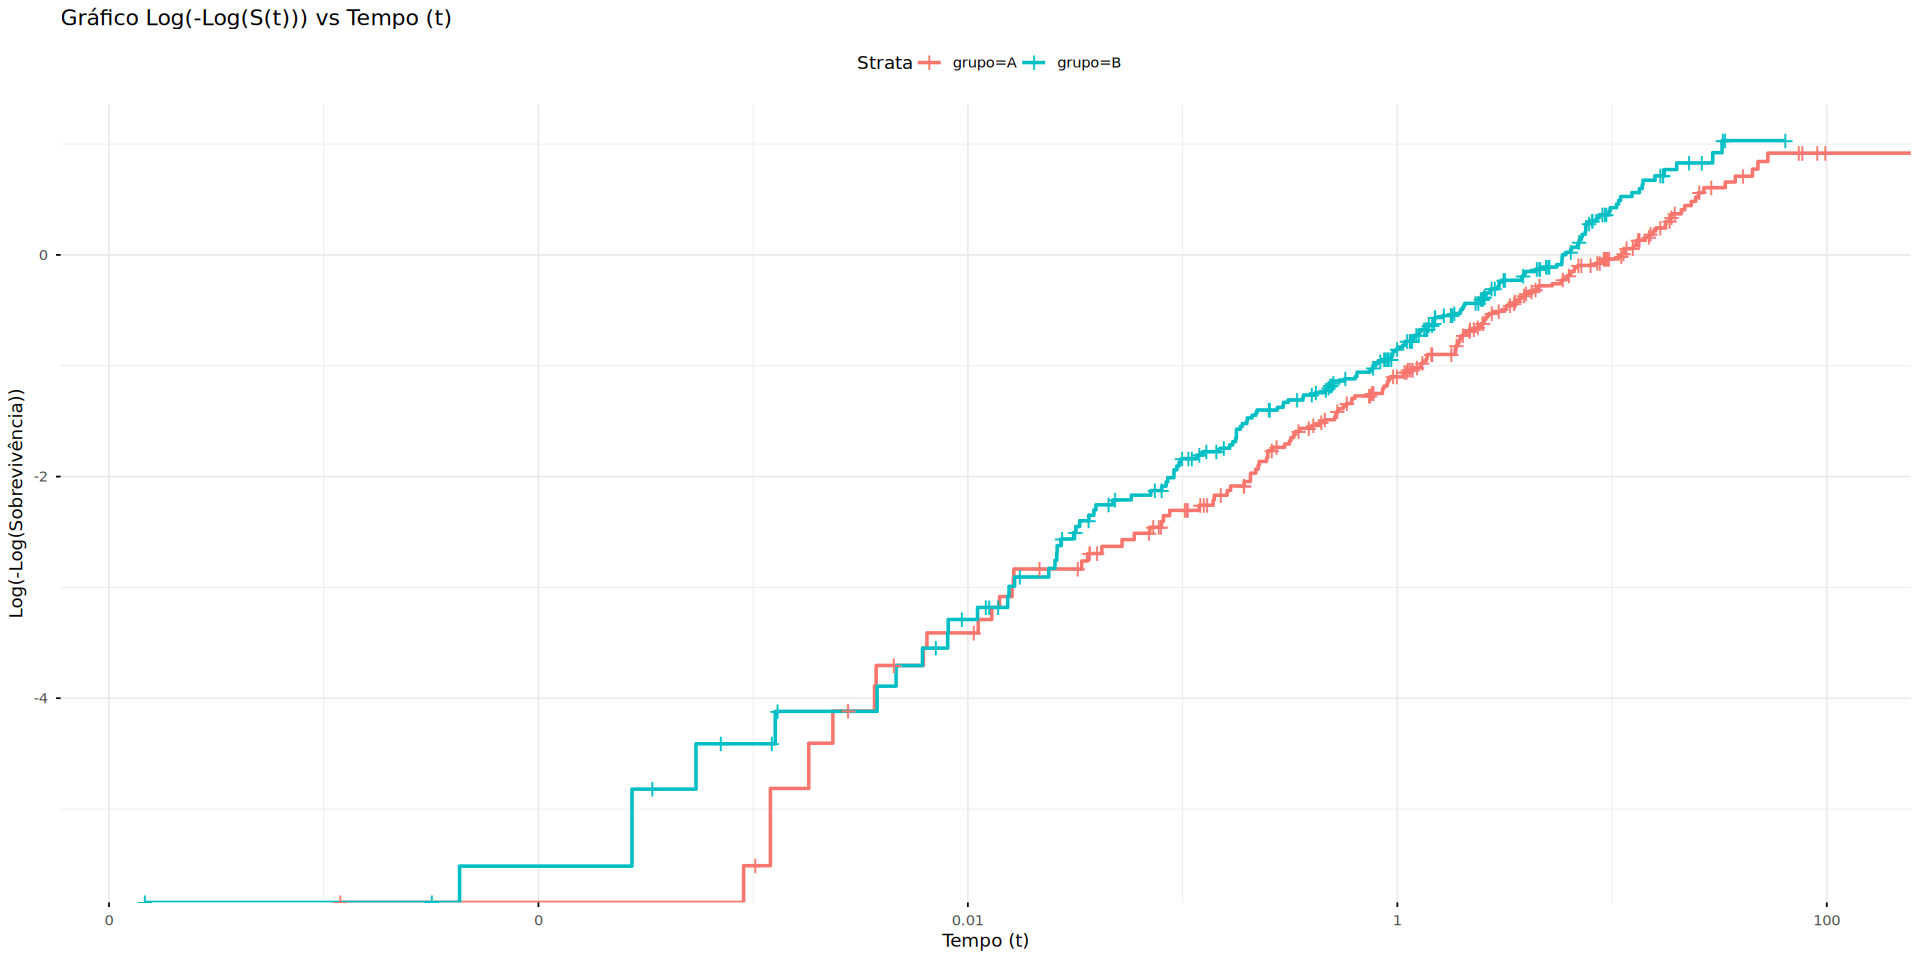

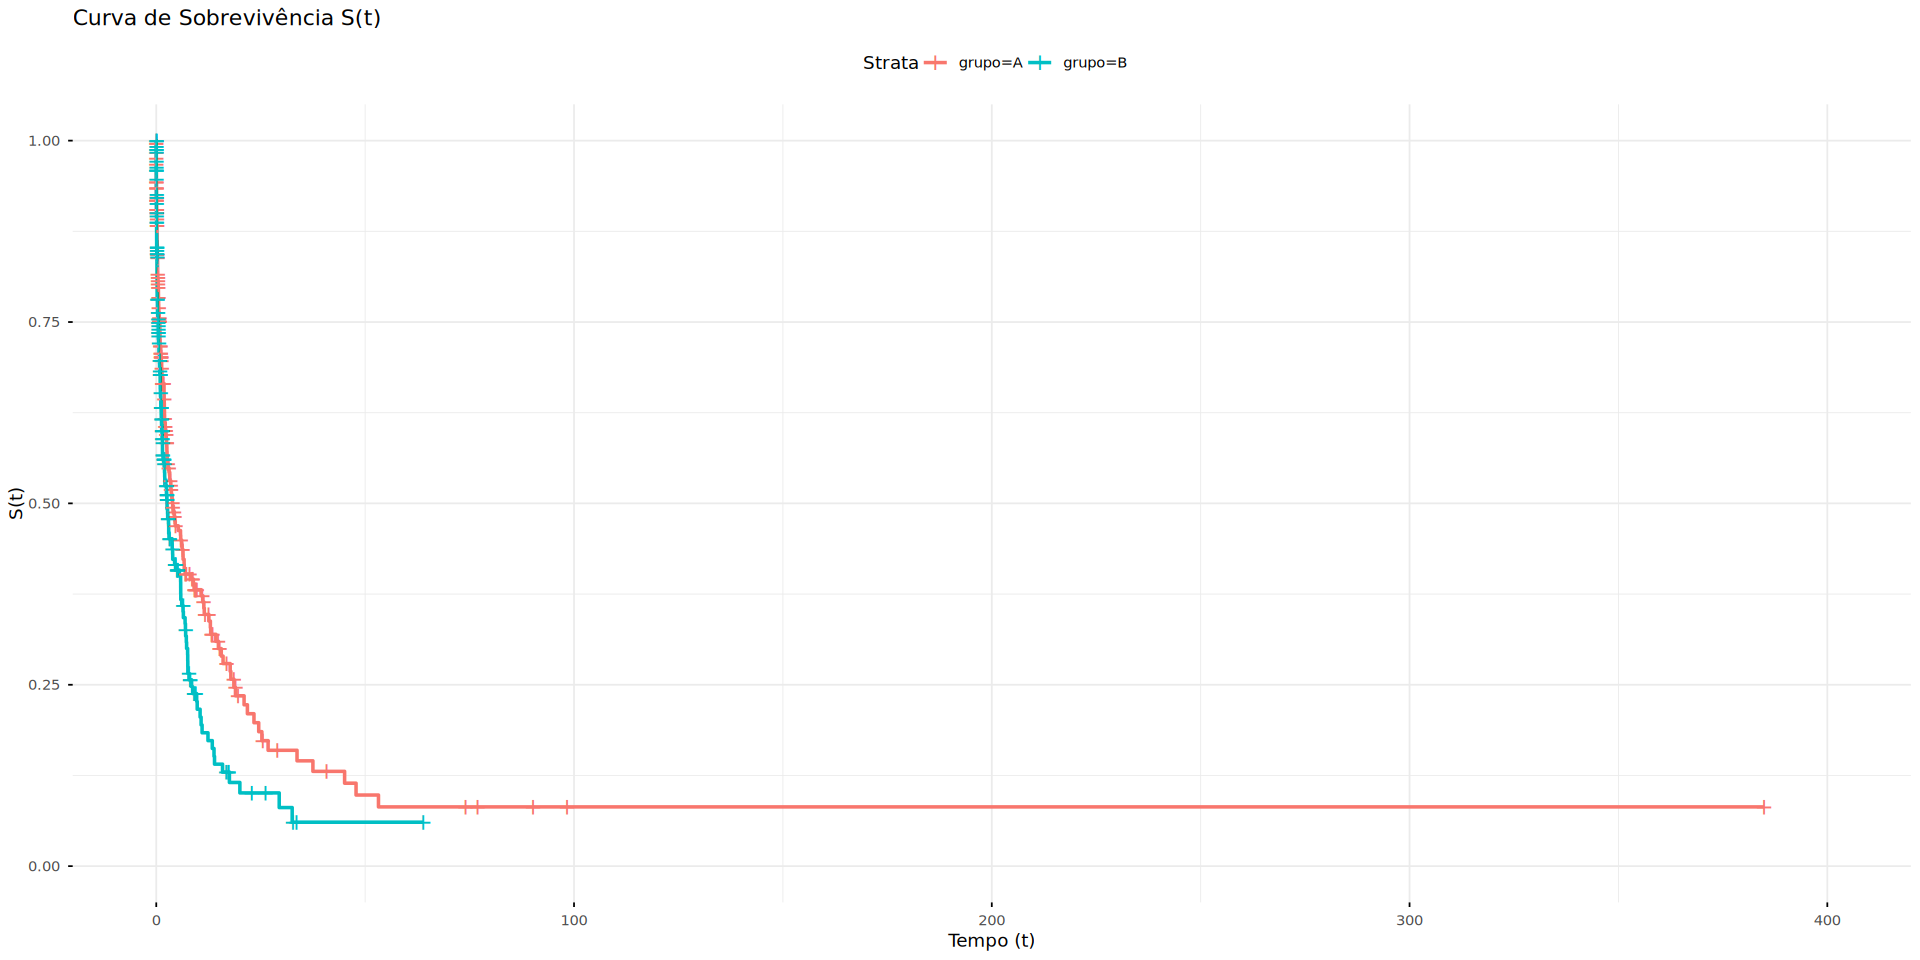

In [103]:
curva <- survfit(Surv(z, delta) ~ grupo, data = dados)
ggsurvplot(curva, 
           fun = "cloglog",   # Aplica log(-log(S(t))) no eixo Y
           # Não usamos nenhum argumento de log para o eixo X
           ggtheme = theme_minimal(),
           title = "Gráfico Log(-Log(S(t))) vs Tempo (t)",
           xlab = "Tempo (t)", 
           ylab = "Log(-Log(Sobrevivência))")

ggsurvplot(
  curva,
  conf.int = FALSE,
  risk.table = FALSE,
  ggtheme = theme_minimal(),
  title = "Curva de Sobrevivência S(t)",
  xlab = "Tempo (t)",
  ylab = "S(t)"
)$plot

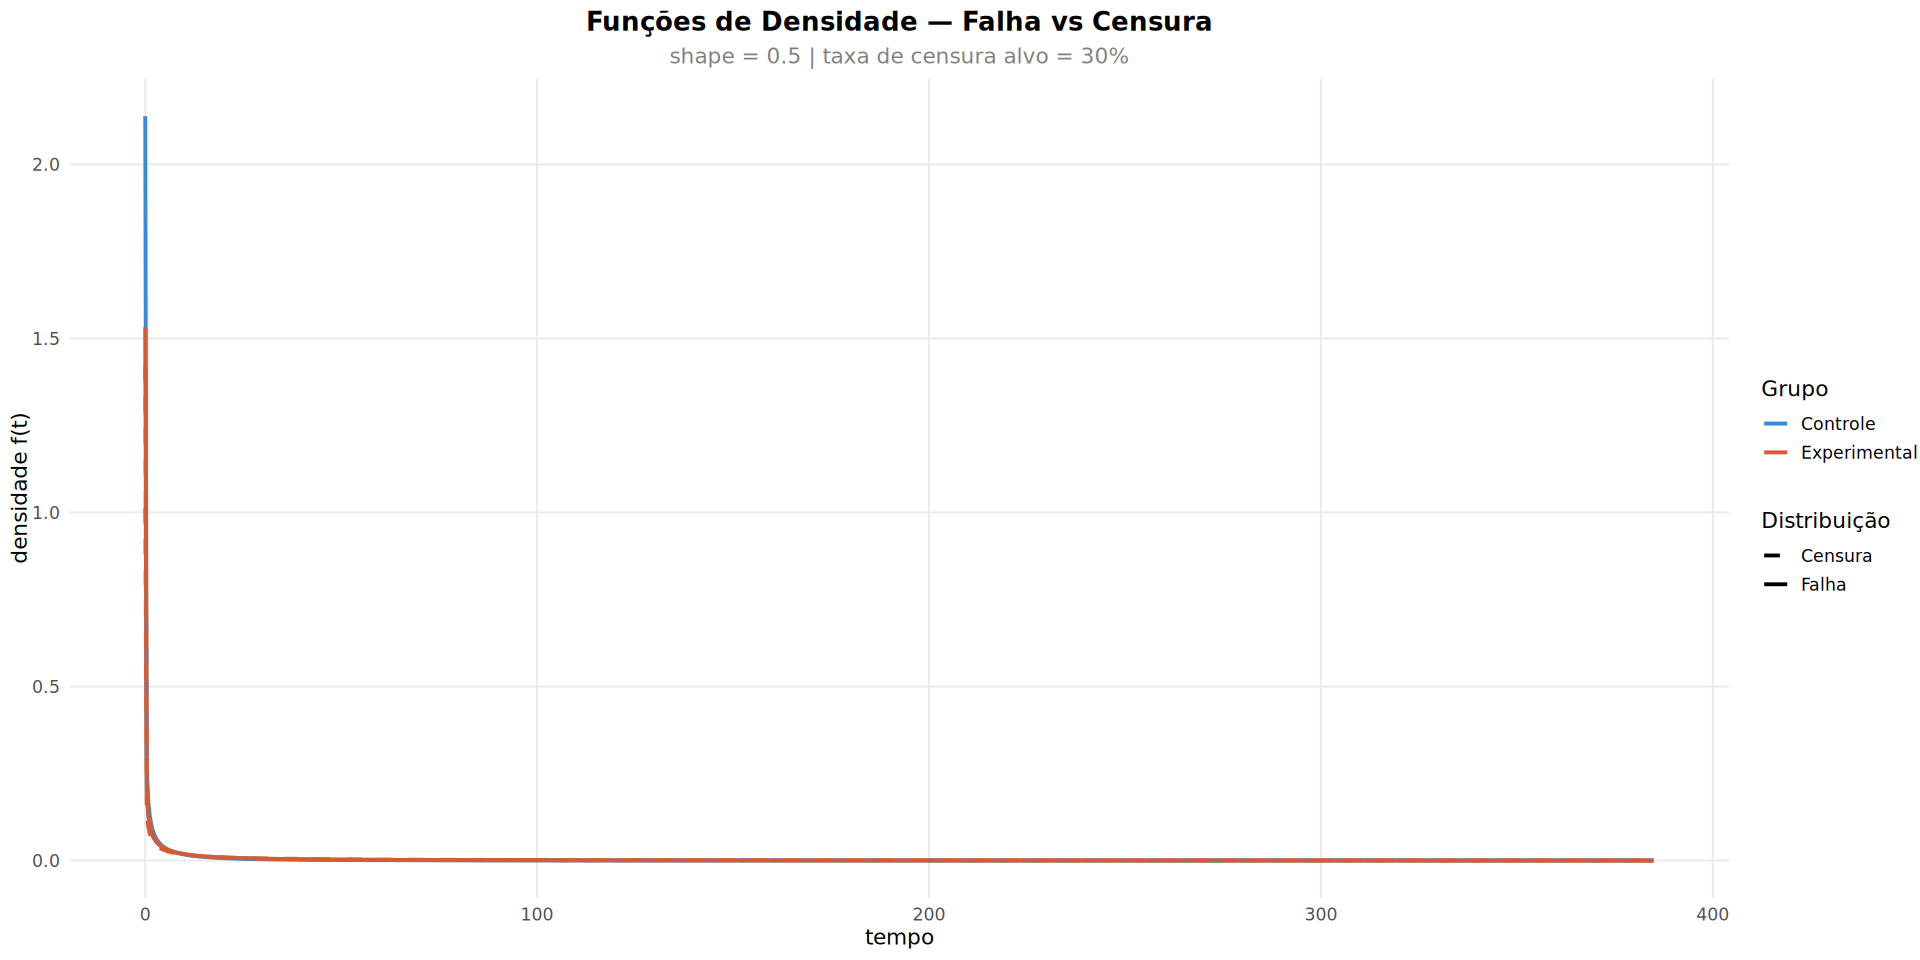

In [104]:
t_seq <- seq(0.01, max(dados$z), length.out = 1000)

fdp_falha_exp  <- dweibull(t_seq, shape = shape_falha_experimental_weibull,  scale = parametro_falha_experimental)
fdp_falha_ctrl <- dweibull(t_seq, shape = shape_falha_controle_weibull,       scale = parametro_falha_controle)
fdp_cens_exp   <- dweibull(t_seq, shape = shape_censura_experimental_weibull, scale = parametro_censura_experimental)
fdp_cens_ctrl  <- dweibull(t_seq, shape = shape_censura_controle_weibull,     scale = parametro_censura_controle)

df_fdp <- data.frame(
  t       = rep(t_seq, 4),
  density = c(fdp_falha_exp, fdp_falha_ctrl, fdp_cens_exp, fdp_cens_ctrl),
  tipo    = rep(c("Falha", "Falha", "Censura", "Censura"), each = 1000),
  grupo   = rep(c("Experimental", "Controle", "Experimental", "Controle"), each = 1000)
)

ggplot(df_fdp, aes(x = t, y = density, color = grupo, linetype = tipo)) +
  geom_line(linewidth = 1.1) +
  scale_color_manual(
    name   = "Grupo",
    values = c("Experimental" = "#D85A30", "Controle" = "#378ADD")
  ) +
  scale_linetype_manual(
    name   = "Distribuição",
    values = c("Falha" = "solid", "Censura" = "dashed")
  ) +
  labs(
    title    = "Funções de Densidade — Falha vs Censura",
    subtitle = paste0("shape = ", shape_falha_experimental_weibull,
                      " | taxa de censura alvo = ", taxa_censura * 100, "%"),
    x = "tempo",
    y = "densidade f(t)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position  = "right",
    legend.box       = "vertical",
    plot.title       = element_text(face = "bold", hjust = 0.5),
    plot.subtitle    = element_text(hjust = 0.5, color = "gray50"),
    panel.grid.minor = element_blank()
  )